# Import packages

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Dataloader

In [12]:
file_path = 'testfile.txt'

In [13]:
def load_data():
    x_list, y_list = [], []
    with open (file_path, 'r') as f:
        for line in f:
            line = line.strip()
            x, y = line.split(',')
            x_list.append(float(x))
            y_list.append(float(y))
        return x_list, y_list

# Matrix operations in numpy

In [14]:
def get_A(n, x_list):
    A = np.zeros((len(x_list), n))
    for i, x in enumerate(x_list):
        for j in range(n):
            A[i][j] = x ** j
    return A

#ref https://johnfoster.pge.utexas.edu/numerical-methods-book/LinearAlgebra_LU.html
def PLU(Matrix, n):
    P = np.identity(n, dtype=np.double)
    L = np.identity(n, dtype=np.double)
    U = Matrix.copy()
    for i in range(n):
        max_row = np.argmax(np.abs(U[i:, i])) + i
        if i != max_row:
            # Swap rows in U and P
            U[[i, max_row], :] = U[[max_row, i], :]
            P[[i, max_row], :] = P[[max_row, i], :]
        for j in range(i + 1, n):
            # do elimination for each entry below pivot
            factor = U[j, i] / U[i, i]
            U[j, i:] -= factor * U[i, i:]
            L[j, i] = factor
    return P, L, U

def solve(A, b, n):
    assert A.shape[0] == A.shape[1], 'Input is not square.'
    n = A.shape[0]
    P, L, U = PLU(A, n)
    b = np.dot(P, b)
    # solve linear system
    #first we solve Ly = b
    y = np.zeros_like(b, dtype=np.double)
    y[0] = b[0] / L[0, 0]
    for i in range(1, n):
        y[i] = (b[i] - np.dot(L[i,:i], y[:i])) / L[i,i]

    #then we solve Ux = y
    x = np.zeros_like(y, dtype=np.double)
    x[-1] = y[-1] / U[-1, -1]
    for i in range(n-2, -1, -1):
        x[i] = (y[i] - np.dot(U[i,i:], x[i:])) / U[i,i]
    return x


# LSE

In [15]:
class LSE:
    def __init__(self, n, Lambda = 0):
        self.n = n
        self.Lambda = Lambda
        self.x_list, self.y_list = load_data()
        self.x_list = np.array(self.x_list)
        self.y_list = np.array(self.y_list)
        self.A = get_A(self.n, self.x_list)
        self.x = None
    
    def LSE_solve(self):
        A = (self.A.T @ self.A) + self.Lambda * np.identity(self.n)
        b = self.A.T @ self.y_list
        x = solve(A, b, self.n)
        return x
    
    def output(self):
        self.x = self.LSE_solve()
        formula = 'Fitting line: '
        for i in range(self.n - 1):
            formula += f'{self.x[self.n - 1 - i]: .13f}X^{self.n - 1 - i} + '
        formula += f'{self.x[0]: .13f}'
        print(formula)
        
        error = (self.A @ self.x.T) - self.y_list
        error = [x**2 for x in error]
        error = np.sum(error)
        print(f'Total error: {error}')

    def plot(self):
        coefficients = np.flip(self.x)
        polynomial = np.poly1d(coefficients)
        x = np.linspace(-6, 6, 30)
        y = polynomial(x)
        plt.scatter(self.x_list, self.y_list, color = 'red', marker='o', )
        plt.plot(x, y, color = 'black')
        plt.title('LSE')
        plt.show()



# Steepest descent

In [16]:
#ref https://towardsdatascience.com/linear-regression-using-gradient-descent-97a6c8700931
class SGD:
    def __init__(self, n, epochs, Lambda = 0, lr = 1e-5):
        self.n = n
        self.epochs = epochs
        self.lr = lr
        self.Lambda = Lambda
        self.coeffs = np.full(self.n, 1e-8)
        self.x_list, self.y_list = load_data()
        self.x_list = np.array(self.x_list)
        self.y_list = np.array(self.y_list)
        self.A = get_A(self.n, self.x_list)
        
    def SGD_solve(self):
        for epoch in range(self.epochs):
            pred_y = self.A @ self.coeffs.T
            # calculate gradient for m and c
            for i in range(self.n):
                d_coeff = 2 * np.sum((self.x_list ** i) @ (pred_y - self.y_list)) + self.Lambda * np.sign(self.coeffs[i])
                self.coeffs[i] -= self.lr * d_coeff
                
    def output(self):
        self.SGD_solve()
        formula = 'Fitting line: '
        for i in range(self.n - 1):
            formula += f'{self.coeffs[self.n - 1 - i]: .13f}X^{self.n - 1 - i} + '
        formula += f'{self.coeffs[0]: .13f}'
        print(formula)
        
        error = (self.A @ self.coeffs.T) - self.y_list
        error = [x**2 for x in error]
        error = np.sum(error)
        print(f'Total error: {error}')
        
    def plot(self):
        coefficients = np.flip(self.coeffs)
        polynomial = np.poly1d(coefficients)
        x = np.linspace(-6, 6, 30)
        y = polynomial(x)
        plt.scatter(self.x_list, self.y_list, color = 'red', marker='o', )
        plt.plot(x, y, color = 'black')
        plt.title('SGD')
        plt.show()



# Newton's Method:

In [17]:
class Newton:
    def __init__(self, n):
        self.n = n
        self.x_list, self.y_list = load_data()
        self.x_list = np.array(self.x_list)
        self.y_list = np.array(self.y_list)
        self.A = get_A(self.n, self.x_list)
        self.x = np.zeros(n, dtype=np.float32)
    def Newton_solve(self):
        hessian = -2 * (self.A.T @ self.A)
        b = -2 * (self.A.T @ self.y_list)
        self.x = solve(hessian, b, self.n)
    
    def output(self):
        self.Newton_solve()
        formula = 'Fitting line: '
        for i in range(self.n - 1):
            formula += f'{self.x[self.n - 1 - i]: .13f}X^{self.n - 1 - i} + '
        formula += f'{self.x[0]: .13f}'
        print(formula)
    
        error = (self.A @ self.x.T) - self.y_list
        error = [x**2 for x in error]
        error = np.sum(error)
        print(f'Total error: {error}')

    def plot(self):
        coefficients = np.flip(self.x)
        polynomial = np.poly1d(coefficients)
        x = np.linspace(-6, 6, 30)
        y = polynomial(x)
        plt.scatter(self.x_list, self.y_list, color = 'red', marker='o', )
        plt.plot(x, y, color = 'black')
        plt.title('Newton\'s Method')
        plt.show()
    

# Sample input & output

Fitting line:  4.4329503100768X^1 +  29.3064047060563
Total error: 16335.123164957966


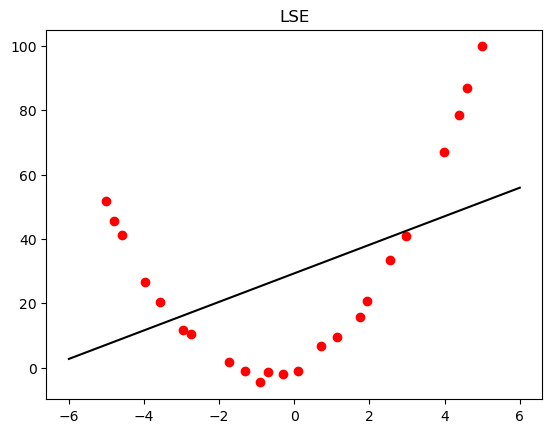

Fitting line:  4.4329503100204X^1 +  29.3064047028624
Total error: 16335.123164957966


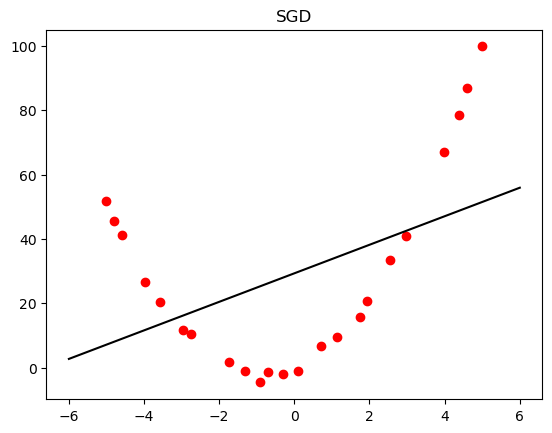

Fitting line:  4.4329503100768X^1 +  29.3064047060563
Total error: 16335.123164957966


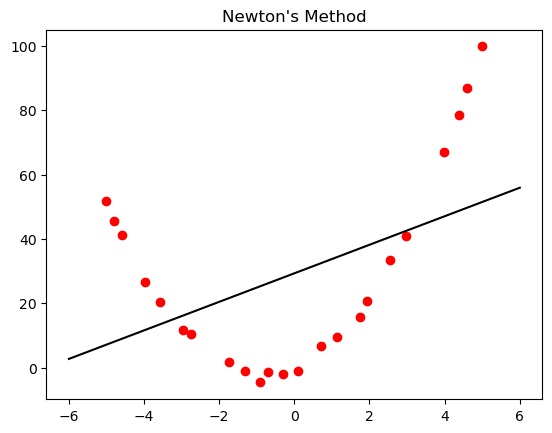

In [29]:
# LSE (n, Lambda = 0)
# SGD (n, epochs, Lambda = 0, lr = 1e-5)
# Newton (n)
LSE_case_1 = LSE(2)
LSE_case_1.output()
LSE_case_1.plot()

SGD_case_1 = SGD(2, 50000)
SGD_case_1.output()
SGD_case_1.plot()

Newton_case_1 = Newton(2)
Newton_case_1.output()
Newton_case_1.plot()



Fitting line:  3.0238533934866X^2 +  4.9061902638638X^1 + -0.2314017560877
Total error: 26.559959499333036


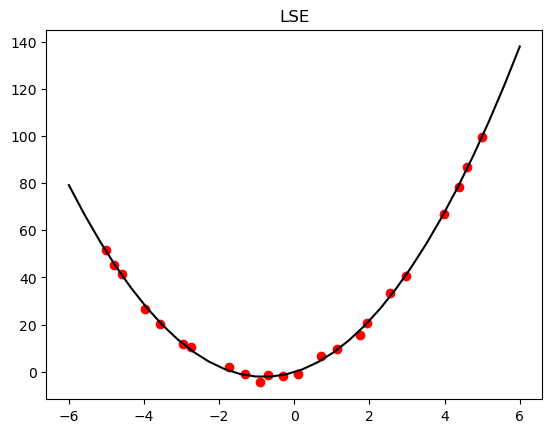

Fitting line:  3.0238533917880X^2 +  4.9061902638085X^1 + -0.2314017260570
Total error: 26.559959499333022


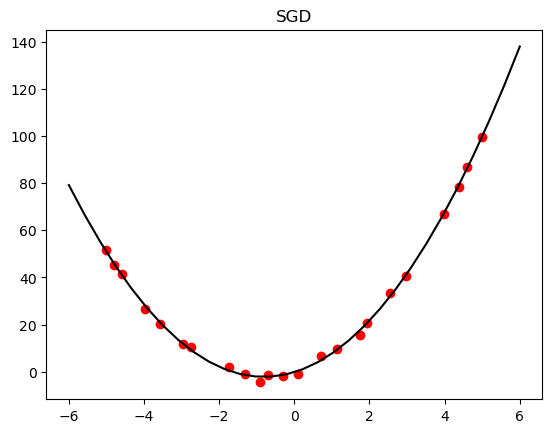

Fitting line:  3.0238533934866X^2 +  4.9061902638638X^1 + -0.2314017560877
Total error: 26.559959499333036


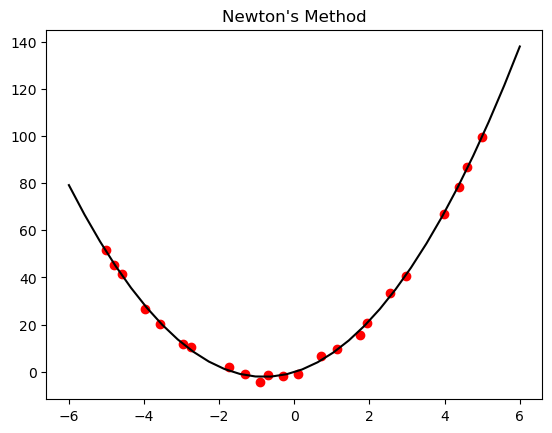

In [37]:
# LSE (n, Lambda = 0)
# SGD (n, epochs, Lambda = 0, lr = 1e-5)
# Newton (n)
LSE_case_2 = LSE(3)
LSE_case_2.output()
LSE_case_2.plot()

SGD_case_2 = SGD(3, 80000)
SGD_case_2.output()
SGD_case_2.plot()

Newton_case_2 = Newton(3)
Newton_case_2.output()
Newton_case_2.plot()

Fitting line:  0.8345332827003X^2 +  0.0931481983192X^1 +  0.0469506992735
Total error: 22649.738493024153


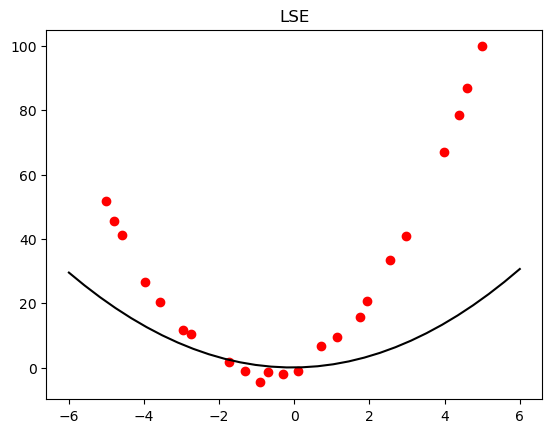

Fitting line:  1.6730783712175X^2 + -0.0181809154455X^1 + -0.0297908768732
Total error: 11729.176795722144


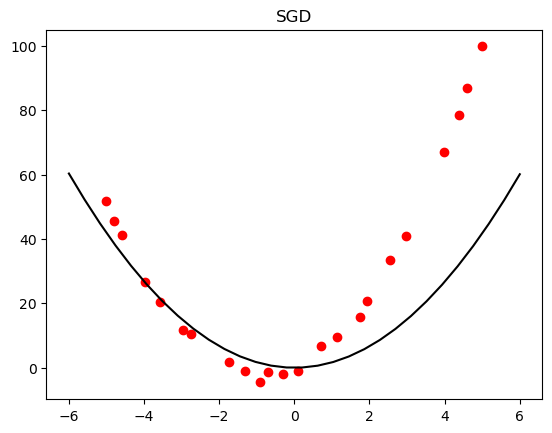

Fitting line:  3.0238533934866X^2 +  4.9061902638638X^1 + -0.2314017560877
Total error: 26.559959499333036


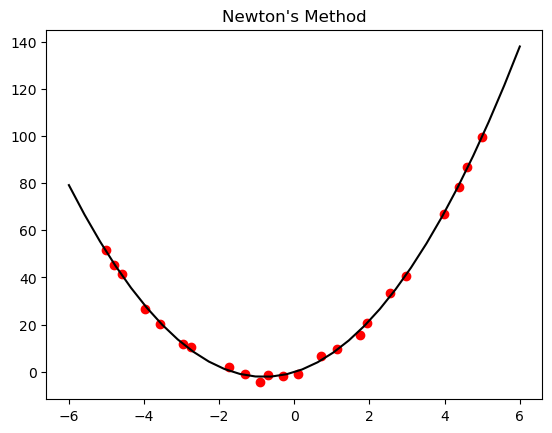

In [49]:
# LSE (n, Lambda = 0)
# SGD (n, epochs, Lambda = 0, lr = 1e-5)
# Newton (n)
LSE_case_3 = LSE(3, Lambda=10000)
LSE_case_3.output()
LSE_case_3.plot()

SGD_case_3 = SGD(3, 70000, Lambda=10000)
SGD_case_3.output()
SGD_case_3.plot()

Newton_case_3 = Newton(3)
Newton_case_3.output()
Newton_case_3.plot()